In [2]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import timeit
import json
from itertools import product
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
from copy import deepcopy
import pickle
import heapq

plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.size'] = 10
cmap_models = cm.get_cmap('Set2')

import warnings
warnings.filterwarnings("ignore")

# Use BADS
import concurrent.futures
from pybads import BADS

import json
import pandas
from collections import Counter

from scipy.stats import binomtest, ttest_rel
import matplotlib.patches as mpatches

import random
from collections import deque
from collections import namedtuple
from typing import List, Tuple, FrozenSet

from itertools import product
import string



import sys
print(sys.version)

pd.set_option('display.max_rows', None)

figpath = os.path.join("fig")
utilpath = os.path.join("utils")

3.11.3 (main, Apr 20 2026, 15:44:30) [Clang 21.0.0 (clang-2100.0.123.102)]


In [ ]:
def find_all_paths(
    reactions_idx: List[Tuple[int, int, int]],
    initial_objects: List[int],
    goal_idx: int,
    max_len: int = 6,
):
    """
    reactions_idx: list of (left_idx, right_idx, product_idx)
    initial_objects: indices of objects initially present
    goal_idx: index of goal object (e.g. obj2idx['Z'])
    max_len: maximum number of reactions allowed in a path
    """
    init_state: FrozenSet[int] = frozenset(initial_objects)
    results: List[List[int]] = []  # each path = list of reaction indices
    visited = {}  # state -> shortest path length found so far

    def dfs(state: FrozenSet[int], path: List[int]):
        # If we already have the goal, record the path and stop expanding
        if goal_idx in state:
            results.append(path.copy())
            return

        # Limit search depth
        if len(path) >= max_len:
            return

        # Prune if we've seen this state with an equal or shorter path
        if state in visited and visited[state] <= len(path):
            return
        visited[state] = len(path)

        # Try all applicable reactions
        for r_idx, (a, b, c) in enumerate(reactions_idx):
            if a in state and b in state and c not in state:
                new_state = set(state)
                new_state.add(c)
                path.append(r_idx)
                dfs(frozenset(new_state), path)
                path.pop()

    dfs(init_state, [])
    return results


def path_to_str(path: List[int]) -> str:
    """Convert a sequence of reaction indices into human-readable chain."""
    steps = []
    for i in path:
        r = reactions_named[i]
        steps.append(f"{r.left} + {r.right} -> {r.product}")
    return ",  ".join(steps)

def objects_used_by_path(path, reactions_idx, idx2obj):
    """
    path: list of reaction indices, e.g. [0, 1, 2]
    reactions_idx: list of (left_idx, right_idx, product_idx)
    idx2obj: dict mapping index -> object name

    Returns:
        used_indices: sorted list of unique object indices
        used_names:   sorted list of corresponding object names
    """
    used = set()
    for r_idx in path:
        a, b, c = reactions_idx[r_idx]
        used.add(a)
        used.add(b)
        used.add(c)

    used_indices = sorted(used)
    used_names = [idx2obj[i] for i in used_indices]
    return used_indices, used_names


## Generate example trials

In [ ]:
import itertools
import numpy as np

# ----- Universe -----
objects = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z']
obj2idx = {o:i for i,o in enumerate(objects)}
idx2obj = {i:o for o,i in obj2idx.items()}
N = len(objects)

def state_tuple_to_vec(tup):
    """tup is a tuple of 0/1 of length N; return np.array int8."""
    return np.array(tup, dtype=np.int8)

def has_all(state, required):
    return all(state[obj2idx[o]] == 1 for o in required)

def has_none(state, forbidden):
    return all(state[obj2idx[o]] == 0 for o in forbidden)

def violates_forbidden_groups(state, forbidden_groups):
    """
    forbidden_groups: list of tuples, e.g. [('A','B'), ('B','C','D')]
    state: binary vector
    obj2idx: mapping from object name -> index in state
    """
    for forbidden in forbidden_groups:
        if all(state[obj2idx[obj]] == 1 for obj in forbidden):
            return True
    return False


def satisfies_any_group(state, groups_any):
    """
    groups_any: list of groups, each group is iterable of object letters,
    interpreted as "ALL letters in this group must be present" for that group to count.
    Requirement: at least one group is fully present.
    Example: [('K','L'), ('F','G'), ('G','H'), ('E','F','L')]
    """
    for group in groups_any:
        if all(state[obj2idx[o]] == 1 for o in group):
            return True
    return False

def generate_states(
    required=(),
    must_absent=(),
    forbidden_groups=(),
    require_any_groups=None
):
    """
    Returns list of np.array binary vectors (length N) satisfying constraints.
    - required: letters that must be 1
    - must_absent: letters that must be 0
    - forbidden_groups: list of (a,b,...) that cannot all be 1
    - require_any_groups: list of groups; at least one group must be fully present
    """
    require_any_groups = require_any_groups or []

    out = []
    for tup in itertools.product([0,1], repeat=N):
        state = tup  # tuple of ints

        if not has_all(state, required):
            continue
        if not has_none(state, must_absent):
            continue
        if forbidden_groups and violates_forbidden_groups(state, forbidden_groups):
            continue
        if require_any_groups and not satisfies_any_group(state, require_any_groups):
            continue

        out.append(state_tuple_to_vec(state))
    return out


# ----- Define the pair constraints referred to as "2-tuples below" -----
forbidden_2tuples = [('K','L'), ('F','G'), ('G','H')]

# ----- Build the dictionary -----
states_by_condition = {}


# # 2) DIJ present, other random
# states_by_condition["DIJ_present_other_random"] = generate_states(
#     require_any_groups=[('D','I','J'), ('E','I','J')])

# # 3) EIJ present, without any of the 2-tuples below (KL, FG, GH)
# states_by_condition["EIJ_present_no_KL_FG_GH"] = generate_states(
#     require_any_groups=[('D','I','J'), ('E','I','J')],
#     forbidden_groups=[('K','L'), ('F','G'), ('G','H')]
# )

# 3) IJ present, without any of the 2-tuples below (KL, FG, GH)
states_by_condition["default_step1_optimaluniq"] = generate_states(
    required=('W','E'),
    forbidden_groups=[('L','M'),('X','E'), ('Y','E'), ('V','E'),('O','E'),('Q','X'),('P','Y')]
)


# 5) DEI present, without J or any of the 2-tuples below
states_by_condition["default_step2_optimaluniq"] = generate_states(
    required=('X','Y','E'),
    forbidden_groups=[('L','M'),('X','E'), ('Y','E'), ('V','E'),('O','E'),('Q','X'),('P','Y'),
                      ('J','K','E'),('F','G','Y'),('H','I','X'),('T','U','E'),('V','N','E')]
)

# 1) IJ present, other random
states_by_condition["default_step1_optimal"] = generate_states(required=('W','E'))

# 6) Einstellung 3, optimal 2. 
states_by_condition["default_step3_einstellung2A"] = generate_states(
    required=('A','B','Y','E'),
    must_absent=('X','W'),
    require_any_groups=[('J','K','E'),('F','G','Y'),('H','I','X'),('T','U','E'),('V','N','E')], # [('A','B','Y','E'),('C','D','X','E')]
    forbidden_groups=[('L','M'),('X','E'), ('Y','E'), ('V','E'),('O','E'),('Q','X'),('P','Y')],  
)

states_by_condition["default_step3_einstellung2B"] = generate_states(
    required=('C','D','X','E'),
    must_absent=('Y','W'),
    require_any_groups=[('J','K','E'),('F','G','Y'),('H','I','X'),('T','U','E'),('V','N','E')], # [('A','B','Y','E'),('C','D','X','E')]
    forbidden_groups=[('L','M'),('X','E'), ('Y','E'), ('V','E'),('O','E'),('Q','X'),('P','Y')],  
)

# 7) Einstellung 4, optimal 2. 
states_by_condition["default_step4_einstellung2"] = generate_states(
    required=('A','B','C','D','E'),
    must_absent=('X','Y','W'),
    require_any_groups=[('J','K','E'),('F','G','Y'),('H','I','X'),('T','U','E'),('V','N','E')], # [('A','B','Y','E'),('C','D','X','E')]
    forbidden_groups=[('L','M'),('X','E'), ('Y','E'), ('V','E'),('O','E'),('Q','X'),('P','Y')],  
)


# # 8) Einstellung 4, optimal 3---non existent.
# states_by_condition["default_step4_einstellung3"] = generate_states(
#     required=('A','B','Y','E',  'T','U','N'),
#     must_absent=('X','Y','W',  'V')
#     require_any_groups=[('J','K','E'),('F','G','Y'),('H','I','X'),('T','U','E'),('V','N','E')], # [('A','B','Y','E'),('C','D','X','E')]
#     forbidden_groups=[('L','M'),('X','E'), ('Y','E'), ('V','E'),('O','E'),('Q','X'),('P,Y')],  
# )



# ----- Optional: print counts -----
for k, v in states_by_condition.items():
    print(f"{k}: {len(v)} states")

# Now `states_by_condition[k]` is a list of np.array vectors (0/1) of length 14.


In [2]:
# Find states that conform to the above, but also have similar P(s_j=1) for different objects j across the trials?

import numpy as np
from collections import OrderedDict

def _as_bytes_key(state_vec: np.ndarray) -> bytes:
    """Hashable key for a 0/1 np array."""
    # Ensure contiguous int8
    s = np.ascontiguousarray(state_vec.astype(np.int8))
    return s.tobytes()

def _objective_from_counts(counts: np.ndarray, total: int) -> float:
    p = counts / total
    return float(np.std(p))
    #return float(np.sum((p - 0.5) ** 2))

def _compute_counts(sampled_by_cond, N):
    counts = np.zeros(N, dtype=np.int64)
    total = 0
    for states in sampled_by_cond.values():
        if len(states) == 0:
            continue
        mat = np.stack(states, axis=0)  # [n, N]
        counts += mat.sum(axis=0).astype(np.int64)
        total += mat.shape[0]
    return counts, total

def sample_unique_and_optimize(
    states_by_condition: dict,
    n_trials_sampled: np.ndarray,
    keys_order=None,
    seed: int = 0,
    max_iters: int = 50_000,
    anneal: bool = True,
    temp0: float = 0.1,
    temp_decay: float = 0.9995,
    verbose: bool = True,
):
    """
    Returns sampled_by_condition: dict[key] -> list[np.array] length n_trials_sampled[i]
    satisfying global uniqueness, optimized to make marginal presence ~ 0.5.

    states_by_condition: dict key -> list of np.array (binary vectors length N)
    n_trials_sampled: length-K array of ints
    keys_order: optional explicit order of keys corresponding to n_trials_sampled
    """
    rng = np.random.default_rng(seed)

    if keys_order is None:
        # preserve insertion order if the dict was created in order; otherwise user should pass keys_order
        keys_order = list(states_by_condition.keys())

    K = len(keys_order)
    if len(n_trials_sampled) != K:
        raise ValueError(f"n_trials_sampled has length {len(n_trials_sampled)} but keys_order has length {K}.")

    # Basic checks and setup
    N = len(states_by_condition[keys_order[0]][0])
    for k in keys_order:
        for s in states_by_condition[k]:
            if len(s) != N:
                raise ValueError("Not all states have the same length N.")

    # Convert candidate pools into arrays and hash keys for overlap checks
    pools = {}
    pool_keys = {}
    for k in keys_order:
        pool = states_by_condition[k]
        if len(pool) < int(n_trials_sampled[keys_order.index(k)]):
            raise ValueError(f"Not enough candidate states in condition {k}: "
                             f"{len(pool)} < required {int(n_trials_sampled[keys_order.index(k)])}.")
        pools[k] = pool
        pool_keys[k] = np.array([_as_bytes_key(s) for s in pool], dtype=object)

    # ---- Step 1: Build a feasible non-overlapping initial sample (greedy randomized) ----
    sampled_by_cond = OrderedDict((k, []) for k in keys_order)
    sampled_keysets = OrderedDict((k, set()) for k in keys_order)
    used_global = set()

    # Greedy order: hardest first (smallest pool relative to need)
    difficulty = []
    for i, k in enumerate(keys_order):
        difficulty.append((len(pools[k]) / max(1, int(n_trials_sampled[i])), i, k))
    difficulty.sort()  # smaller ratio first

    for _, i, k in difficulty:
        need = int(n_trials_sampled[i])
        # random permutation of indices, take those not used globally
        idxs = rng.permutation(len(pools[k]))
        picked = []
        for idx in idxs:
            key = pool_keys[k][idx]
            if key in used_global:
                continue
            picked.append(idx)
            if len(picked) == need:
                break
        if len(picked) < need:
            raise RuntimeError(
                f"Could not find enough non-overlapping states for {k}. "
                "Constraints may be infeasible given pool overlaps."
            )

        for idx in picked:
            s = pools[k][idx]
            key = pool_keys[k][idx]
            sampled_by_cond[k].append(s)
            sampled_keysets[k].add(key)
            used_global.add(key)

    counts, total = _compute_counts(sampled_by_cond, N)
    best_obj = _objective_from_counts(counts, total)
    best_sample = {k: list(v) for k, v in sampled_by_cond.items()}
    best_keysets = {k: set(v) for k, v in sampled_keysets.items()}
    if verbose:
        print(f"[init] objective={best_obj:.6f}  total_states={total}")

    # ---- Helpers for fast delta evaluation ----
    # Precompute per-state vectors for each pool (as int8) for quick sums
    pool_mat = {k: np.stack(pools[k], axis=0).astype(np.int8) for k in keys_order}

    # Map from key->index inside each pool for fast removal/add
    key_to_index = {}
    for k in keys_order:
        d = {}
        for idx, key in enumerate(pool_keys[k]):
            d[key] = idx
        key_to_index[k] = d

    # ---- Step 2: Local search by swaps within a condition (keep per-condition sample size fixed) ----
    # Move: pick condition k, pick one currently selected state, replace with an unselected & globally-unused candidate
    temp = temp0

    for it in range(max_iters):
        # pick a random condition
        ci = rng.integers(0, K)
        k = keys_order[ci]
        if len(sampled_by_cond[k]) == 0:
            continue

        # choose a selected state to remove
        rem_j = rng.integers(0, len(sampled_by_cond[k]))
        rem_state = sampled_by_cond[k][rem_j]
        rem_key = _as_bytes_key(rem_state)
        rem_vec = rem_state.astype(np.int64)

        # try a few random candidates to add
        n_tries = 5
        improved = False

        for _ in range(n_tries):
            add_idx = rng.integers(0, len(pools[k]))
            add_key = pool_keys[k][add_idx]

            # must not be globally used (except if it's the one we are removing)
            if add_key in used_global and add_key != rem_key:
                continue

            add_state = pools[k][add_idx]
            add_vec = add_state.astype(np.int64)

            # compute objective delta quickly
            new_counts = counts - rem_vec + add_vec
            new_obj = _objective_from_counts(new_counts, total)

            accept = False
            if new_obj <= best_obj:
                accept = True
            elif anneal:
                # simulated annealing acceptance
                # scale by temp; if temp small, very unlikely to accept worse moves
                prob = np.exp(-(new_obj - best_obj) / max(1e-12, temp))
                if rng.random() < prob:
                    accept = True

            if accept:
                # apply swap
                # update global used set:
                used_global.remove(rem_key)
                used_global.add(add_key)

                # update condition-specific set:
                sampled_keysets[k].remove(rem_key)
                sampled_keysets[k].add(add_key)

                # replace in list:
                sampled_by_cond[k][rem_j] = add_state

                # update counts / objective
                counts = new_counts
                best_obj = new_obj

                # store best snapshot occasionally (or always)
                best_sample = {kk: list(vv) for kk, vv in sampled_by_cond.items()}
                best_keysets = {kk: set(vv) for kk, vv in sampled_keysets.items()}

                improved = True
                break

        if anneal:
            temp *= temp_decay

        if verbose and (it + 1) % 5000 == 0:
            print(f"[iter {it+1}] objective={best_obj:.6f} temp={temp:.6f}")

        # Early stop if we're “close enough”
        if best_obj < 1e-6:
            if verbose:
                print(f"[stop] objective ~ 0 at iter {it+1}")
            break

    # Return best found
    return best_sample


In [ ]:
# states_by_condition: dict from earlier (key -> list[np.array] of shape [N])
# n_trials_sampled: np.array of length 7
# trial_counts = [1,1,1,1,1,5,2,2]
# trial_counts = [1,1,1,1,1,5,5,2]

trial_counts = [2,1,2,5,2,2]
trial_counts = [3,1,2,5,3,2]
keys_order = list(states_by_condition.keys())
sampled = sample_unique_and_optimize(
    states_by_condition,
    n_trials_sampled=np.array(trial_counts),
    keys_order=keys_order,
    seed=0,
    max_iters=50_000,
    anneal=True,
    verbose=True
)

# sampled is dict: key -> list of binary state vectors


[init] objective=0.200098  total_states=16
[iter 5000] objective=0.182440 temp=0.008203
[iter 10000] objective=0.143961 temp=0.000673


In [ ]:
sampled

In [28]:
def sampled_binary_to_letters(sampled, objects):
    """
    sampled: dict[key] -> list[np.array] of shape (N,), entries in {0,1}
    objects: list of length N, mapping index -> object letter

    Returns:
        sampled_letters: dict[key] -> list[list[str]]
    """
    sampled_letters = {}

    for k, states in sampled.items():
        trials_as_letters = []
        for state in states:
            letters = [objects[i] for i, v in enumerate(state) if v == 1]
            trials_as_letters.append(letters)
        sampled_letters[k] = trials_as_letters

    return sampled_letters

sampled_letters = sampled_binary_to_letters(sampled, objects)

# Inspect one condition
for i in range(len(sampled_letters)):
    cond = list(sampled_letters.keys())[i]
    print(cond)
    print(sampled_letters[cond],"\n")   # e.g. ['A','B','C','D','I','J']


IJ_present_no_KL_FG_GH
[['B', 'F', 'H', 'I', 'J', 'K'], ['C', 'D', 'F', 'H', 'I', 'J', 'K'], ['D', 'F', 'H', 'I', 'J', 'K']] 

DEI_present_no_J_no_KL_FG_GH
[['A', 'B', 'C', 'D', 'E', 'F', 'H', 'I', 'L']] 

IJ_present_other_random
[['C', 'D', 'F', 'H', 'I', 'J', 'K', 'L'], ['B', 'D', 'F', 'G', 'H', 'I', 'J']] 

DEI_present_no_J_with_one_of_KL_FG_GH
[['A', 'B', 'D', 'E', 'G', 'H', 'I', 'K', 'L'], ['A', 'C', 'D', 'E', 'F', 'G', 'I', 'L'], ['A', 'D', 'E', 'F', 'G', 'I', 'K', 'L'], ['C', 'D', 'E', 'G', 'I', 'K', 'L'], ['A', 'B', 'D', 'E', 'F', 'G', 'H', 'I', 'L']] 

ABEI_present_no_D_J_KL_FG_GH_with_one_of_EFL_BCG
[['A', 'B', 'C', 'E', 'G', 'I', 'L'], ['A', 'B', 'C', 'E', 'F', 'I', 'L'], ['A', 'B', 'C', 'E', 'G', 'I', 'K']] 

ABEI_present_no_D_no_J_with_one_of_KL_FG_GH_EFL_BCG
[['A', 'B', 'C', 'E', 'G', 'H', 'I', 'K'], ['A', 'B', 'C', 'E', 'G', 'H', 'I', 'K', 'L']] 



(16, 12)
[6 7 6 9 8 7 9 8 8 7 9 7 7 7 8 9]


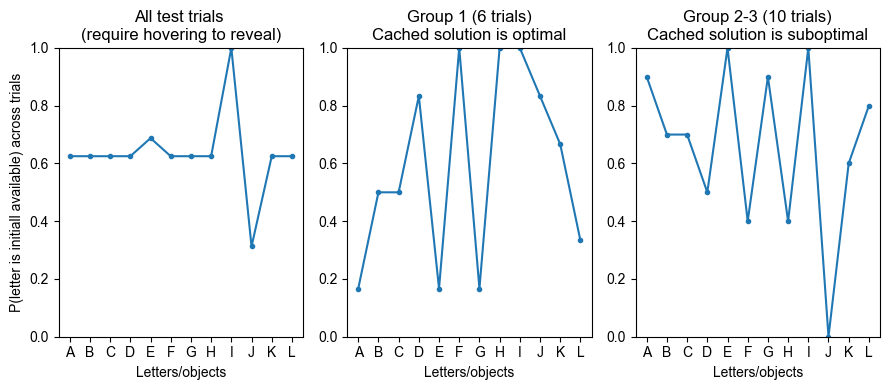

In [29]:
# How even are P(s_j=1)'s? 
def collapse_sampled_dict(sampled, keys_order=None):
    """
    sampled: dict[key] -> list of np.array (binary state vectors)
    keys_order: optional explicit ordering of keys
    
    Returns:
        X: np.ndarray shape (n_trials_total, n_objects)
        cond_idx: np.ndarray shape (n_trials_total,) mapping each row to condition index
        cond_keys: list of condition keys in index order
    """
    if keys_order is None:
        keys_order = list(sampled.keys())

    rows = []
    cond_idx = []

    for ci, k in enumerate(keys_order):
        states = sampled[k]
        for s in states:
            rows.append(s)
            cond_idx.append(ci)

    X = np.stack(rows, axis=0)
    cond_idx = np.array(cond_idx, dtype=int)

    return X, cond_idx, keys_order

final_trials, cond_idx, cond_keys = collapse_sampled_dict(sampled, keys_order)
print(final_trials.shape)         # (total_trials, n_objects)
print(np.sum(final_trials,axis=1)) # number of object present on each trial

# Visualize P(s_j=1) for each object, averaged over trials.
titles = ["All test trials \n(require hovering to reveal)", "Group 1 (6 trials)\nCached solution is optimal", "Group 2-3 (10 trials)\nCached solution is suboptimal"]
fig,ax = plt.subplots(1,3, figsize=(9,4))
ax[0].plot(range(len(objects)),np.mean(final_trials, axis=0),".-")
ax[1].plot(range(len(objects)),np.mean(final_trials[0:6], axis=0),".-")
ax[2].plot(range(len(objects)),np.mean(final_trials[6:], axis=0),".-")
for col in range(3):
    ax[col].set_xticks(ticks=range(len(objects)),labels=objects)
    ax[col].set_ylim([0,1])
    ax[col].set_title(titles[col])
    ax[col].set_xlabel("Letters/objects")
ax[0].set_ylabel("P(letter is initiall available) across trials")
fig.tight_layout()
plt.savefig(os.path.join("fig_exp2","prob_initially_available.png"), dpi=200)
plt.show()

In [30]:
# Add in P(s_j=1) = 0 for goal object
zeros_col = np.zeros((final_trials.shape[0], 1), dtype=final_trials.dtype)
# Horizontally stack the original array and the zero column
final_trials_pad = np.hstack((final_trials, zeros_col))
final_trials_pad

array([[0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0],
       [1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0],
       [0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0],
       [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0],
       [1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0],
       [1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0],
       [1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0],
       [1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0],
       [1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0],
       [1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0],
       [1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0],
       [1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0]], dtype=int8)

#### More training trials?

In [64]:
# states_by_condition: dict from earlier (key -> list[np.array] of shape [N])
# n_trials_sampled: np.array of length 7
# trial_counts = [1,1,1,1,1,5,2,2]
# trial_counts = [1,1,1,1,1,5,5,2]
states_by_condition_train = {}
states_by_condition_train["one_step"] = generate_states(
    require_any_groups=[('I','J')],
    forbidden_groups = [('K','L'), ('F','G'), ('G','H'),('E','F','L'), ('B','C','G')], 
)
states_by_condition_train["two_step"] = generate_states(
    forbidden_groups = [('I','J'),('K','L'), ('F','G'), ('G','H'), ('E','F','L'), ('B','C','G')],
    require_any_groups=[('D','E','I')]
)
states_by_condition_train["three_step"] = generate_states(
    forbidden_groups = [('I','J'),('D','E','I'),('K','L'), ('F','G'), ('G','H'), ('E','F','L'), ('B','C','G')],
    require_any_groups=[('A','B','E','I')]
)



trial_counts = [2,6,4]
keys_order = list(states_by_condition_train.keys())   # or your explicit preferred order
sampled_train = sample_unique_and_optimize(
    states_by_condition_train,
    n_trials_sampled=np.array(trial_counts),
    keys_order=keys_order,
    seed=0,
    max_iters=50_000,
    anneal=True,
    verbose=True
)

# sampled is dict: key -> list of binary state vectors


[init] objective=0.257601  total_states=12
[iter 5000] objective=0.255627 temp=0.008203
[iter 10000] objective=0.202583 temp=0.000673
[iter 15000] objective=0.191948 temp=0.000055
[iter 20000] objective=0.191948 temp=0.000005
[iter 25000] objective=0.191948 temp=0.000000
[iter 30000] objective=0.191948 temp=0.000000
[iter 35000] objective=0.191948 temp=0.000000
[iter 40000] objective=0.191948 temp=0.000000
[iter 45000] objective=0.191948 temp=0.000000
[iter 50000] objective=0.191948 temp=0.000000


In [65]:
sampled_train

{'one_step': [array([0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1], dtype=int8),
  array([0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1], dtype=int8)],
 'two_step': [array([1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0], dtype=int8),
  array([0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0], dtype=int8),
  array([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1], dtype=int8),
  array([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0], dtype=int8),
  array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1], dtype=int8),
  array([1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1], dtype=int8)],
 'three_step': [array([1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1], dtype=int8),
  array([1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0], dtype=int8),
  array([1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0], dtype=int8),
  array([1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0], dtype=int8)]}

In [66]:
sampled_letters_train = sampled_binary_to_letters(sampled_train, objects)

# Inspect one condition
for i in range(len(sampled_letters_train)):
    cond = list(sampled_letters_train.keys())[i]
    print(cond)
    print(sampled_letters_train[cond],"\n")   # e.g. ['A','B','C','D','I','J']


one_step
[['B', 'C', 'D', 'F', 'H', 'I', 'J', 'L'], ['C', 'F', 'H', 'I', 'J', 'L']] 

two_step
[['A', 'D', 'E', 'G', 'I', 'K'], ['C', 'D', 'E', 'F', 'H', 'I', 'K'], ['C', 'D', 'E', 'G', 'I', 'L'], ['A', 'B', 'C', 'D', 'E', 'F', 'H', 'I', 'K'], ['B', 'D', 'E', 'G', 'I', 'L'], ['A', 'C', 'D', 'E', 'G', 'I', 'L']] 

three_step
[['A', 'B', 'E', 'G', 'I', 'L'], ['A', 'B', 'E', 'G', 'I', 'K'], ['A', 'B', 'E', 'F', 'H', 'I', 'K'], ['A', 'B', 'C', 'E', 'F', 'H', 'I', 'K']] 



(12, 12)
[8 6 6 7 6 9 6 7 6 6 7 8]


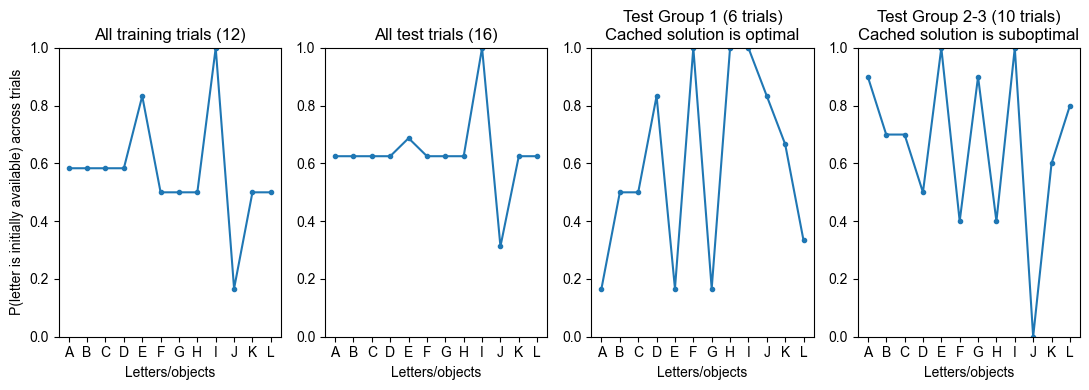

In [67]:
# How even are P(s_j=1)'s? 
def collapse_sampled_dict(sampled, keys_order=None):
    """
    sampled: dict[key] -> list of np.array (binary state vectors)
    keys_order: optional explicit ordering of keys
    
    Returns:
        X: np.ndarray shape (n_trials_total, n_objects)
        cond_idx: np.ndarray shape (n_trials_total,) mapping each row to condition index
        cond_keys: list of condition keys in index order
    """
    if keys_order is None:
        keys_order = list(sampled.keys())

    rows = []
    cond_idx = []

    for ci, k in enumerate(keys_order):
        states = sampled[k]
        for s in states:
            rows.append(s)
            cond_idx.append(ci)

    X = np.stack(rows, axis=0)
    cond_idx = np.array(cond_idx, dtype=int)

    return X, cond_idx, keys_order

final_trials_train, cond_idx_train, cond_keys_train = collapse_sampled_dict(sampled_train, keys_order)
print(final_trials_train.shape)         # (total_trials, n_objects)
print(np.sum(final_trials_train,axis=1)) # number of object present on each trial

# Visualize P(s_j=1) for each object, averaged over trials.
titles = ["All training trials (12)", "All test trials (16)", "Test Group 1 (6 trials)\nCached solution is optimal", "Test Group 2-3 (10 trials)\nCached solution is suboptimal"]
fig,ax = plt.subplots(1,4, figsize=(11,4))
ax[0].plot(range(len(objects)),np.mean(final_trials_train, axis=0),".-")
ax[1].plot(range(len(objects)),np.mean(final_trials, axis=0),".-")
ax[2].plot(range(len(objects)),np.mean(final_trials[0:6], axis=0),".-")
ax[3].plot(range(len(objects)),np.mean(final_trials[6:], axis=0),".-")
for col in range(4):
    ax[col].set_xticks(ticks=range(len(objects)),labels=objects)
    ax[col].set_ylim([0,1])
    ax[col].set_title(titles[col])
    ax[col].set_xlabel("Letters/objects")
ax[0].set_ylabel("P(letter is initially available) across trials")
fig.tight_layout()
plt.savefig(os.path.join("fig_exp2","prob_initially_available.png"), dpi=200)
plt.show()